In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import zipfile, os

zip_name = "archive (6).zip"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extraction complete")


Extraction complete


In [4]:
import os

gray_path = "/content/dataset/landscapeImages/gray"
color_path = "/content/dataset/landscapeImages/color"

print("Gray images :", len(os.listdir(gray_path)))
print("Color images:", len(os.listdir(color_path)))


Gray images : 7129
Color images: 7129


In [5]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

def load_image_pair(gray_path, color_path):
    gray = tf.io.read_file(gray_path)
    gray = tf.image.decode_image(gray, channels=1, expand_animations=False)
    gray = tf.image.resize(gray, [IMG_HEIGHT, IMG_WIDTH])
    gray = tf.cast(gray, tf.float32) / 255.0
    gray = (gray * 2.0) - 1.0

    color = tf.io.read_file(color_path)
    color = tf.image.decode_image(color, channels=3, expand_animations=False)
    color = tf.image.resize(color, [IMG_HEIGHT, IMG_WIDTH])
    color = tf.cast(color, tf.float32) / 255.0
    color = (color * 2.0) - 1.0

    return gray, color


In [6]:
gray_files = sorted([
    os.path.join(gray_path, f)
    for f in os.listdir(gray_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

color_files = sorted([
    os.path.join(color_path, f)
    for f in os.listdir(color_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print(len(gray_files), len(color_files))


7129 7129


In [7]:
BATCH_SIZE = 16
BUFFER_SIZE = 1000

dataset = tf.data.Dataset.from_tensor_slices((gray_files, color_files))
dataset = dataset.map(
    lambda g, c: load_image_pair(g, c),
    num_parallel_calls=tf.data.AUTOTUNE
)
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print("Dataset ready")


Dataset ready


In [8]:
from tensorflow.keras import layers, models

def build_generator():
    inputs = layers.Input(shape=(128, 128, 1))

    x = layers.Conv2D(64, 4, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(128, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(512, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", activation="relu")(x)

    outputs = layers.Conv2DTranspose(
        3, 4, strides=2, padding="same", activation="tanh"
    )(x)

    return models.Model(inputs, outputs)

generator = build_generator()
generator.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 3)    │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,514,115 (21.03 MB)

 Trainable params: 5,512,323 (21.03 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [9]:
def build_discriminator():
    inputs = layers.Input(shape=(128, 128, 3))

    x = layers.Conv2D(64, 4, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(128, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)

    outputs = layers.Dense(1)(x)
    return models.Model(inputs, outputs)

discriminator = build_discriminator()
discriminator.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        65,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 724,929 (2.77 MB)

 Trainable params: 724,673 (2.76 MB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

gen_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


In [11]:
LAMBDA = 50

def generator_loss(fake_output, fake_color, real_color):
    gan_loss = loss_fn(tf.ones_like(fake_output), fake_output)
    l1_loss = tf.reduce_mean(tf.abs(real_color - fake_color))
    return gan_loss + LAMBDA * l1_loss


In [12]:
@tf.function
def train_step(gray, real_color):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_color = generator(gray, training=True)

        real_output = discriminator(real_color, training=True)
        fake_output = discriminator(fake_color, training=True)

        gen_loss = generator_loss(fake_output, fake_color, real_color)
        disc_loss = (
            loss_fn(tf.ones_like(real_output), real_output) +
            loss_fn(tf.zeros_like(fake_output), fake_output)
        )

    gen_optimizer.apply_gradients(
        zip(gen_tape.gradient(gen_loss, generator.trainable_variables),
            generator.trainable_variables)
    )
    disc_optimizer.apply_gradients(
        zip(disc_tape.gradient(disc_loss, discriminator.trainable_variables),
            discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


In [13]:
EPOCHS = 40

for epoch in range(EPOCHS):
    for gray, color in dataset:
        g_loss, d_loss = train_step(gray, color)

    print(f"Epoch {epoch+1}/{EPOCHS} | G: {g_loss:.4f} | D: {d_loss:.4f}")


Epoch 1/40 | G: 12.5864 | D: 1.0049
Epoch 2/40 | G: 10.0401 | D: 1.6984
Epoch 3/40 | G: 11.4492 | D: 0.7365
Epoch 4/40 | G: 10.4413 | D: 2.6233
Epoch 5/40 | G: 11.4903 | D: 0.7006
Epoch 6/40 | G: 10.0039 | D: 0.8256
Epoch 7/40 | G: 8.8227 | D: 0.8360
Epoch 8/40 | G: 12.0699 | D: 0.4540
Epoch 9/40 | G: 9.8397 | D: 0.9060
Epoch 10/40 | G: 10.2620 | D: 0.6365
Epoch 11/40 | G: 11.0562 | D: 0.5496
Epoch 12/40 | G: 9.6642 | D: 0.5988
Epoch 13/40 | G: 10.0598 | D: 0.7620
Epoch 14/40 | G: 8.8354 | D: 0.7923
Epoch 15/40 | G: 9.0172 | D: 0.7844
Epoch 16/40 | G: 9.3532 | D: 1.1114
Epoch 17/40 | G: 9.8079 | D: 0.9357
Epoch 18/40 | G: 11.4459 | D: 1.3299
Epoch 19/40 | G: 10.2861 | D: 0.8121
Epoch 20/40 | G: 10.2686 | D: 0.5996
Epoch 21/40 | G: 9.0975 | D: 0.7676
Epoch 22/40 | G: 10.0565 | D: 0.5018
Epoch 23/40 | G: 9.1189 | D: 0.7481
Epoch 24/40 | G: 9.2010 | D: 0.4877
Epoch 25/40 | G: 9.5576 | D: 0.9856
Epoch 26/40 | G: 10.9998 | D: 0.4776
Epoch 27/40 | G: 9.1296 | D: 0.6607
Epoch 28/40 | G: 9.793

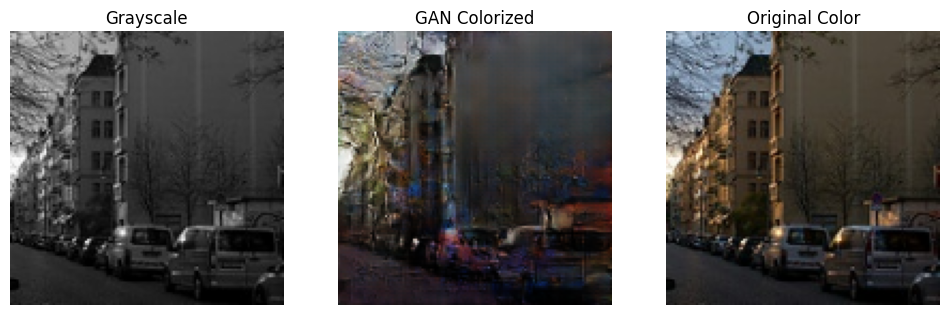

In [14]:
import matplotlib.pyplot as plt

def compare_results(index=0):
    gray_img, real_color = load_image_pair(gray_files[index], color_files[index])
    gray_img = tf.expand_dims(gray_img, axis=0)

    fake_color = generator(gray_img, training=False)[0]

    fake_color = (fake_color + 1) / 2
    real_color = (real_color + 1) / 2
    gray_img = (gray_img + 1) / 2

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(gray_img[0][:,:,0], cmap='gray')
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(fake_color)
    plt.title("GAN Colorized")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(real_color)
    plt.title("Original Color")
    plt.axis("off")

    plt.show()

compare_results(0)
